In [19]:
import numpy as np
import qutip
import sympy
from hetero_isas.monodromy_lp import (
    MonodromyLPDecomposer,
    MonodromyLPGate,
    MonodromyLPISA,
)
from hetero_isas.monodromy_lp.invariants import (
    mono_coordinates_to_CAN,
    recover_local_equivalence,
)
from hetero_isas.monodromy_lp.isa import ISAHandler
from monodromy.coordinates import unitary_to_monodromy_coordinate
from monodromy.static.qlr_table import generate_qlr_inequalities
from numpy.random import Philox
from qiskit import QuantumCircuit
from qiskit.circuit.library import CXGate, CZGate, SwapGate, UnitaryGate, iSwapGate
from qiskit.quantum_info import Operator, average_gate_fidelity, random_unitary
from qutip import Qobj
from scipy.optimize import linprog
from sympy import Symbol, im, re, simplify, solve, sqrt
from sympy.matrices import Matrix
from sympy.physics.quantum import TensorProduct
from sympy.physics.quantum.dagger import Dagger
from sympy.simplify.cse_main import cse
from weylchamber import c1c2c3
from sympy import exp


generator = Philox(0)

%matplotlib inline

In [32]:
SxSx = Matrix([[0, 0, 0, 1], [0, 0, 1, 0], [0, 1, 0, 0], [1, 0, 0, 0]])
SySy = Matrix([[+0, 0, 0, -1], [+0, 0, 1, 0], [+0, 1, 0, 0], [-1, 0, 0, 0]])
SzSz = Matrix([[1, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, 1]])


def symbol_canonical_gate(a, b, c):
    if not isinstance(a, (int, float)):
        a = Symbol(a, real=True, positive=True)
    if not isinstance(b, (int, float)):
        b = Symbol(b, real=True, positive=True)
    if not isinstance(c, (int, float)):
        c = Symbol(c, real=True, positive=True)

    return Matrix(-1j * (a * SxSx + b * SySy + c * SzSz)).exp()


def symbol_canonical_gate(a, b, c):
    if not isinstance(a, (int, float)):
        a = Symbol(a, real=True, positive=True)
    if not isinstance(b, (int, float)):
        b = Symbol(b, real=True, positive=True)
    if not isinstance(c, (int, float)):
        c = Symbol(c, real=True, positive=True)

    return simplify(
        Matrix(
            [
                [
                    exp(-1j * c) * sympy.cos(a - b),
                    0,
                    0,
                    sympy.sin(a - b) * (-1j * sympy.cos(c) - sympy.sin(c)),
                ],
                [
                    0,
                    exp(1j * c) * sympy.cos(a + b),
                    sympy.sin(a + b) * (-1j * sympy.cos(c) + sympy.sin(c)),
                    0,
                ],
                [
                    0,
                    sympy.sin(a + b) * (-1j * sympy.cos(c) + sympy.sin(c)),
                    exp(1j * c) * sympy.cos(a + b),
                    0,
                ],
                [
                    sympy.sin(a - b) * (-1j * sympy.cos(c) - sympy.sin(c)),
                    0,
                    0,
                    exp(-1j * c) * sympy.cos(a - b),
                ],
            ]
        )
    )

In [34]:
# simplify(symbol_canonical_gate("x", "y", "z"))

Matrix([
[           exp(-1.0*I*z)*cos(x - y),                                  0,                                  0, -(sin(z) + 1.0*I*cos(z))*sin(x - y)],
[                                  0,            exp(1.0*I*z)*cos(x + y), (sin(z) - 1.0*I*cos(z))*sin(x + y),                                   0],
[                                  0, (sin(z) - 1.0*I*cos(z))*sin(x + y),            exp(1.0*I*z)*cos(x + y),                                   0],
[-(sin(z) + 1.0*I*cos(z))*sin(x - y),                                  0,                                  0,            exp(-1.0*I*z)*cos(x - y)]])

In [36]:
MAGIC = Matrix([[1, 0, 0, 1j], [0, 1j, 1, 0], [0, 1j, -1, 0], [1, 0, 0, -1j]]) / sqrt(2)


def symbolic_invariants(U):
    Um = Dagger(MAGIC) * (U * MAGIC)
    det_um = Um.det()
    M = Um.T * Um
    m_tr2 = M.trace()
    m_tr2 *= m_tr2
    G1 = m_tr2 / (16 * det_um)
    G2 = (m_tr2 - (M * M).trace()) / (4 * det_um)
    return re(G1), im(G1), G2


# U = symbol_canonical_gate("a", "b", "c")
U = simplify(
    symbol_canonical_gate("a", "b", "c") * symbol_canonical_gate("x", "y", "z")
)
U

Matrix([
[        ((sin(c) + 1.0*I*cos(c))*(sin(z) + 1.0*I*cos(z))*exp(1.0*I*(c + z))*sin(a - b)*sin(x - y) + cos(a - b)*cos(x - y))*exp(-1.0*I*(c + z)),                                                                                                                       0,                                                                                                                       0, (-(sin(c) + 1.0*I*cos(c))*exp(1.0*I*c)*sin(a - b)*cos(x - y) - (sin(z) + 1.0*I*cos(z))*exp(1.0*I*z)*sin(x - y)*cos(a - b))*exp(-1.0*I*(c + z))],
[                                                                                                                                             0,        (sin(c) - 1.0*I*cos(c))*(sin(z) - 1.0*I*cos(z))*sin(a + b)*sin(x + y) + exp(1.0*I*(c + z))*cos(a + b)*cos(x + y), (sin(c) - 1.0*I*cos(c))*exp(1.0*I*z)*sin(a + b)*cos(x + y) + (sin(z) - 1.0*I*cos(z))*exp(1.0*I*c)*sin(x + y)*cos(a + b),                                                                         

In [37]:
simplify(symbolic_invariants(symbo  l_canonical_gate("x", "y", "z")))

(0.0625*re((((sin(z) + 1.0*I*cos(z))*exp(1.0*I*z)*sin(x - y) - cos(x - y))**2 + ((sin(z) + 1.0*I*cos(z))*exp(1.0*I*z)*sin(x - y) + cos(x - y))**2 + (1.0*(exp(I*(2*x + 2*y))/2 + exp(-I*(2*x + 2*y))/2)*exp(2.0*I*z) - 1.0*exp(2*I*z) + 1.0*exp(2.0*I*z) + 0.5*exp(I*(2*x + 2*y + 2*z)) + 0.5*exp(-I*(2*x + 2*y - 2*z)))*exp(2.0*I*z))**2*exp(-2.0*I*z)/(((sin(z) - 1.0*I*cos(z))*sin(x + y) - exp(1.0*I*z)*cos(x + y))*((sin(z) - 1.0*I*cos(z))*sin(x + y) + exp(1.0*I*z)*cos(x + y))*((sin(z) + 1.0*I*cos(z))*exp(1.0*I*z)*sin(x - y) - cos(x - y))*((sin(z) + 1.0*I*cos(z))*exp(1.0*I*z)*sin(x - y) + cos(x - y)))), 0.0625*im((((sin(z) + 1.0*I*cos(z))*exp(1.0*I*z)*sin(x - y) - cos(x - y))**2 + ((sin(z) + 1.0*I*cos(z))*exp(1.0*I*z)*sin(x - y) + cos(x - y))**2 + (1.0*(exp(I*(2*x + 2*y))/2 + exp(-I*(2*x + 2*y))/2)*exp(2.0*I*z) - 1.0*exp(2*I*z) + 1.0*exp(2.0*I*z) + 0.5*exp(I*(2*x + 2*y + 2*z)) + 0.5*exp(-I*(2*x + 2*y - 2*z)))*exp(2.0*I*z))**2*exp(-2.0*I*z)/(((sin(z) - 1.0*I*cos(z))*sin(x + y) - exp(1.0*I*z)*cos(x

In [5]:
subs, expr = cse(simplify(symbolic_invariants(U)))
expr = expr[0]
for sub_expr in expr:
    print(sub_expr)

-x15*x5 - 0.125*x16*x17
-x15*x16 + 0.125*x17*x5
0.125*I*(-4*x51**4 - 0.25*x59**4 + 0.25*x60*x61 - 4*x62*x63 - (0.25*x61 + x64)**2 - (x63 + 0.25*x65)**2 + 4.0*(-0.25*x60 + 0.125*x61 + 1.0*x62 + 0.5*x63 + 0.5*x64 + 0.125*x65)**2)/(x51*x54*(0.5*x37 + 0.5*x39)*(0.5*x57 - 0.5*x58))


In [5]:
def rv(v: str):
    v = np.array(
        [
            Symbol(f"{v}0", real=True),
            Symbol(f"{v}1", real=True),
            Symbol(f"{v}2", real=True),
        ]
    )
    half_angle = sqrt(v.dot(v)) / 2
    nx, ny, nz = v / (2 * half_angle)
    sin = sympy.sin(half_angle)
    cos = sympy.cos(half_angle)
    return Matrix(
        [
            [cos - 1j * nz * sin, (-ny - 1j * nx) * sin],
            [(ny - 1j * nx) * sin, cos + 1j * nz * sin],
        ],
    )


# too slow without cse
# expr_1q = simplify(TensorProduct(rv("q1v"), rv("q2v")))
# expr_1q
expr_1q_subs, expr_1q = cse(simplify(TensorProduct(rv("q1v"), rv("q2v"))))
expr_1q = expr_1q[0]  # unwrap after cse

In [6]:
left = simplify(symbol_canonical_gate("a", "b", "c") * expr_1q)
left

Matrix([
[0.5*(x13*x6*(exp(I*(-a + b + c)) + exp(I*(a - b + c))) + x21*x24*(exp(I*(-a + b + c)) - exp(I*(a - b + c))))*exp(-2*I*c), 0.5*(x15*x16*(exp(I*(-a + b + c)) + exp(I*(a - b + c))) - x22*x23*(exp(I*(-a + b + c)) - exp(I*(a - b + c))))*exp(-2*I*c), 0.5*(x19*x6*(exp(I*(-a + b + c)) + exp(I*(a - b + c))) - x21*x26*(exp(I*(-a + b + c)) - exp(I*(a - b + c))))*exp(-2*I*c), 0.5*(x15*x20*(exp(I*(-a + b + c)) + exp(I*(a - b + c))) + x22*x25*(exp(I*(-a + b + c)) - exp(I*(a - b + c))))*exp(-2*I*c)],
[                                0.5*(x16*x21*(exp(2*I*(a + b)) + 1) + x23*x6*(1 - exp(2*I*(a + b))))*exp(I*(-a - b + c)),                                0.5*(-x13*x22*(exp(2*I*(a + b)) + 1) + x15*x24*(1 - exp(2*I*(a + b))))*exp(I*(-a - b + c)),                                 0.5*(x20*x21*(exp(2*I*(a + b)) + 1) - x25*x6*(1 - exp(2*I*(a + b))))*exp(I*(-a - b + c)),                                0.5*(-x15*x26*(1 - exp(2*I*(a + b))) - x19*x22*(exp(2*I*(a + b)) + 1))*exp(I*(-a - b + c))],
[      

In [7]:
totu = simplify(left @ simplify(symbol_canonical_gate("x", "y", "z")))
totu

Matrix([
[0.25*((x13*x6*(exp(I*(-a + b + c)) + exp(I*(a - b + c))) + x21*x24*(exp(I*(-a + b + c)) - exp(I*(a - b + c))))*(exp(I*(-x + y + z)) + exp(I*(x - y + z))) + (x15*x20*(exp(I*(-a + b + c)) + exp(I*(a - b + c))) + x22*x25*(exp(I*(-a + b + c)) - exp(I*(a - b + c))))*(exp(I*(-x + y + z)) - exp(I*(x - y + z))))*exp(-2*I*(c + z)), 0.25*((1 - exp(2*I*(x + y)))*(x19*x6*(exp(I*(-a + b + c)) + exp(I*(a - b + c))) - x21*x26*(exp(I*(-a + b + c)) - exp(I*(a - b + c)))) + (x15*x16*(exp(I*(-a + b + c)) + exp(I*(a - b + c))) - x22*x23*(exp(I*(-a + b + c)) - exp(I*(a - b + c))))*(exp(2*I*(x + y)) + 1))*exp(-I*(2*c + x + y - z)), 0.25*((1 - exp(2*I*(x + y)))*(x15*x16*(exp(I*(-a + b + c)) + exp(I*(a - b + c))) - x22*x23*(exp(I*(-a + b + c)) - exp(I*(a - b + c)))) + (x19*x6*(exp(I*(-a + b + c)) + exp(I*(a - b + c))) - x21*x26*(exp(I*(-a + b + c)) - exp(I*(a - b + c))))*(exp(2*I*(x + y)) + 1))*exp(-I*(2*c + x + y - z)), 0.25*((x13*x6*(exp(I*(-a + b + c)) + exp(I*(a - b + c))) + x21*x24*(exp(I*(-a +

In [8]:
totu_subs, totu_simple = cse(totu)
totu_simple = totu_simple[0]
totu_simple

Matrix([
[ x27*(x10*x2 + x11*x17),  x35*(x30*x31 + x32*x33),  x35*(x30*x33 + x31*x32),  x27*(x10*x11 + x17*x2)],
[ x47*(x11*x45 + x2*x42), x50*(-x30*x48 + x32*x49),  x50*(x30*x49 - x32*x48),  x47*(x11*x42 + x2*x45)],
[x47*(-x11*x52 - x2*x54),  x50*(x30*x55 - x32*x56), x50*(-x30*x56 + x32*x55), x47*(-x11*x54 - x2*x52)],
[ x27*(x11*x62 + x2*x59),  x35*(x30*x63 + x32*x64),  x35*(x30*x64 + x32*x63),  x27*(x11*x59 + x2*x62)]])

In [9]:
totu_invariants = symbolic_invariants(totu_simple)  # ~ 12 mins

In [10]:
simplified_invariants = simplify(totu_invariants)

In [11]:
invariant_subs, simp_invariant_cse = cse(simplified_invariants)
simp_invariant_cse = simp_invariant_cse[0]
simp_invariant_cse

(-0.00390625*re(x241), -0.00390625*im(x241), (-x258**2 - x272**2 - x285**2 - x297**2 + (x258 + x272 + x285 + x297)**2 - 2*(x247*x262 + x255*x269 + x298*x299 + x300*x301)**2 - 2*(x247*x277 + x255*x282 + x298*x302 + x300*x303)**2 - 2*(x247*x289 + x255*x294 + x298*x304 + x300*x305)**2 - 2*(x262*x277 + x269*x282 + x299*x302 + x301*x303)**2 - 2*(x262*x289 + x269*x294 + x299*x304 + x301*x305)**2 - 2*(x277*x289 + x282*x294 + x302*x304 + x303*x305)**2)/(4.0*x0*x10*x108*x48*x56*x62*x67*x88 + 4.0*x0*x10*x108*x49*x55*x62*x67*x97 + 4.0*x0*x10*x48*x56*x62*x67*x87*x97 + 4.0*x0*x10*x49*x55*x62*x67*x87*x88 + 4.0*x0*x108*x17*x48*x56*x59*x67*x97 + 4.0*x0*x108*x17*x49*x55*x59*x67*x88 + 4.0*x0*x17*x48*x56*x59*x67*x87*x88 + 4.0*x0*x17*x49*x55*x59*x67*x87*x97 + 4.0*x10*x108*x27*x35*x45*x47*x50*x55*x64*x88 + 4.0*x10*x108*x27*x35*x45*x47*x50*x56*x63*x88 + 4.0*x10*x108*x27*x35*x47*x48*x50*x52*x64*x97 + 4.0*x10*x108*x27*x35*x47*x49*x50*x52*x63*x97 + 4.0*x10*x27*x35*x45*x47*x50*x55*x64*x87*x97 + 4.0*x10*x27*x35*

In [37]:
simplify(
    symbolic_invariants(
        simplify(symbol_canonical_gate("a", 0, 0) * symbol_canonical_gate("d", 0, 0))
    )
)

(0.5*re((0.5*(-0.5*exp(2*I*(a + d)) + 1.0*exp(I*(a + d))*cos(a + d) + 0.5)**2 + 0.5*(-0.5*exp(2*I*(a + d)) + exp(I*(a + d))*cos(a + d) + 0.5)**2 + (0.5*exp(2*I*(a + d)) + exp(I*(a + d))*cos(a + d) - 0.5)**2)**2/((-0.5*exp(2*I*(a + d)) + 1.0*exp(I*(a + d))*cos(a + d) + 0.5)*(-0.25*exp(2*I*(a + d)) + 0.5*exp(I*(a + d))*cos(a + d) + 0.25)*(0.5*exp(2*I*(a + d)) + 1.0*exp(I*(a + d))*cos(a + d) - 0.5)*(2.0*exp(2*I*(a + d)) + 4.0*exp(I*(a + d))*cos(a + d) - 2.0))), 0.5*im((0.5*(-0.5*exp(2*I*(a + d)) + 1.0*exp(I*(a + d))*cos(a + d) + 0.5)**2 + 0.5*(-0.5*exp(2*I*(a + d)) + exp(I*(a + d))*cos(a + d) + 0.5)**2 + (0.5*exp(2*I*(a + d)) + exp(I*(a + d))*cos(a + d) - 0.5)**2)**2/((-0.5*exp(2*I*(a + d)) + 1.0*exp(I*(a + d))*cos(a + d) + 0.5)*(-0.25*exp(2*I*(a + d)) + 0.5*exp(I*(a + d))*cos(a + d) + 0.25)*(0.5*exp(2*I*(a + d)) + 1.0*exp(I*(a + d))*cos(a + d) - 0.5)*(2.0*exp(2*I*(a + d)) + 4.0*exp(I*(a + d))*cos(a + d) - 2.0))), 0.125*I*(-(sqrt(2)*(-0.5*sqrt(2)*I*(0.5 - 0.5*exp(2*I*(a + d)))*exp(-I*(a +

In [38]:
[
    simplify(a - b)
    for a, b in zip(
        simplify(
            symbolic_invariants(
                simplify(
                    symbol_canonical_gate("a", 0, 0) * symbol_canonical_gate("d", 0, 0)
                )
            )
        ),
        simplify(symbolic_invariants(symbol_canonical_gate("x", "y", "z"))),
    )
]

In [22]:
solve(
    a - b
    for a, b in zip(
        symbolic_invariants(
            symbol_canonical_gate("a", "b", "c") * symbol_canonical_gate("d", "f", "g")
        ),
        symbolic_invariants(symbol_canonical_gate("x", "y", "z")),
    )
)

IndexError: Index out of range: a[1]

In [56]:
from sympy import solve

solve(
    (
        expr_i - simp_invariant_cse_i
        for expr_i, simp_invariant_cse_i in zip(expr, simp_invariant_cse)
    )
)

: 

In [25]:
# # from qiskit.synthesis.two_qubit.weyl import transform_to_magic_basis
# from qiskit.synthesis.two_qubit.weyl import _B_nonnormalized, _B_nonnormalized_dagger


# # def transform_to_magic_basis(U):
# #     return _B_nonnormalized @ U @ _B_nonnormalized_dagger


# # transform_to_magic_basis(symbol_canonical_gate("a", "b", "c"))

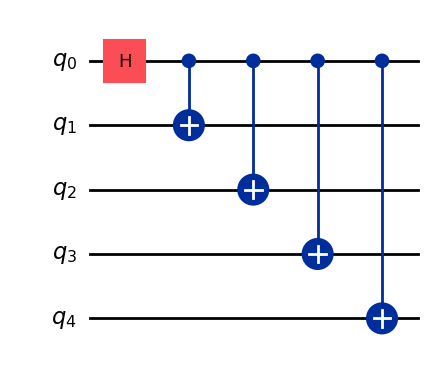

In [43]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(N := 5)
qc.h(0)
for i in range(1, N):
    qc.cx(0, i)
qc.draw("mpl");

In [44]:
Operator(qc)

Operator([[ 0.70710678+0.j,  0.70710678+0.j,  0.        +0.j, ...,
            0.        +0.j,  0.        +0.j,  0.        +0.j],
          [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
            0.        +0.j,  0.70710678+0.j, -0.70710678+0.j],
          [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j, ...,
            0.        +0.j,  0.        +0.j,  0.        +0.j],
          ...,
          [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j, ...,
            0.        +0.j,  0.        +0.j,  0.        +0.j],
          [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
            0.        +0.j,  0.70710678+0.j,  0.70710678+0.j],
          [ 0.70710678+0.j, -0.70710678+0.j,  0.        +0.j, ...,
            0.        +0.j,  0.        +0.j,  0.        +0.j]],
         input_dims=(2, 2, 2, 2, 2), output_dims=(2, 2, 2, 2, 2))


In [49]:
from qutip import Qobj

Qobj(Operator(qc))

Quantum object: dims=[[32], [32]], shape=(32, 32), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.70710678  0.70710678  0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.70710678
  -0.70710678]
 [ 0.          0.          0.70710678 ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.70710678 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.70710678
   0.70710678]
 [ 0.70710678 -0.70710678  0.         ...  0.          0.
   0.        ]]

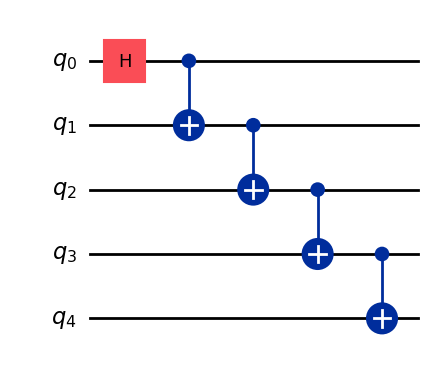

In [45]:
qc2 = QuantumCircuit(N := 5)
qc2.h(0)
for i in range(N - 1):
    qc2.cx(i, i + 1)
qc2.draw("mpl");

In [46]:
Operator(qc2).data

array([[ 0.70710678+0.j,  0.70710678+0.j,  0.        +0.j, ...,
         0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j, ...,
         0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
         0.        +0.j,  0.        +0.j,  0.        +0.j],
       ...,
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j, ...,
         0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j, ...,
         0.        +0.j,  0.        +0.j,  0.        +0.j],
       [ 0.70710678+0.j, -0.70710678+0.j,  0.        +0.j, ...,
         0.        +0.j,  0.        +0.j,  0.        +0.j]])

In [50]:
Qobj(Operator(qc2))

Quantum object: dims=[[32], [32]], shape=(32, 32), type='oper', dtype=Dense, isherm=False
Qobj data =
[[ 0.70710678  0.70710678  0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.70710678 ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.70710678 ...  0.          0.
   0.        ]
 [ 0.70710678 -0.70710678  0.         ...  0.          0.
   0.        ]]

In [52]:
Operator(qc).equiv(Operator(qc2))

False